<a href="https://colab.research.google.com/github/IraSamsonova/nn/blob/main/mushrooms!.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("maysee/mushrooms-classification-common-genuss-images")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'mushrooms-classification-common-genuss-images' dataset.
Path to dataset files: /kaggle/input/mushrooms-classification-common-genuss-images


In [ ]:
import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models, datasets
from PIL import Image, ImageFile
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from collections import Counter
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

игнорирование поврежденных изображений

In [ ]:
ImageFile.LOAD_TRUNCATED_IMAGES = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

dataset_path = "/root/.cache/kagglehub/datasets/maysee/mushrooms-classification-common-genuss-images/versions/1"

Using device: cuda


анализ распределениыя по классам на дисбаланс

---



In [ ]:
def analyze_dataset(dataset_path):

    dataset_path_correct = os.path.join(dataset_path, "Mushrooms")
    dataset = datasets.ImageFolder(dataset_path_correct)

    #метки классов
    labels = [label for _, label in dataset.samples]
    class_counts = Counter(labels)

    print("Распределение данных по классам:")
    for i, class_name in enumerate(dataset.classes):
        count = class_counts[i]
        print(f"{class_name}: {count} изображений")

    total_images = sum(class_counts.values())
    print(f"\nВсего изображений: {total_images}")

    return dataset.classes

class_names = analyze_dataset(dataset_path)

Распределение данных по классам:
Agaricus: 353 изображений
Amanita: 750 изображений
Boletus: 1073 изображений
Cortinarius: 836 изображений
Entoloma: 364 изображений
Hygrocybe: 316 изображений
Lactarius: 1563 изображений
Russula: 1148 изображений
Suillus: 311 изображений

Всего изображений: 6714


Кастомный класс датасета для загрузки и обработки изображений грибов, обрабатывает ошибки при загрузке поврежденных файлов

In [ ]:
class MushroomDataset(Dataset):

    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        label = self.labels[idx]

        try:
            with Image.open(path) as img:
                image = img.convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, label

        except Exception as e:
            #создаем черное изображение
            print(f"Error loading {path}: {e}")
            image = torch.zeros(3, 224, 224) if self.transform else Image.new('RGB', (224, 224))
            return image, label

трансформации

In [ ]:
#для обучающих с аугментацией
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),              #случайное обрезание
    transforms.RandomHorizontalFlip(),       #случайное отражение
    transforms.RandomRotation(10),           #случайный поворот
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),                   #в тензор PyTorch
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  #нормализация
])

#для тестовых данных без аугментации
test_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),              #центральное обрезание
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [ ]:
# Загружаем данные
dataset_path_correct = os.path.join(dataset_path, "Mushrooms")
dataset = datasets.ImageFolder(dataset_path_correct)

# Получаем пути к изображениям и метки
paths = [sample[0] for sample in dataset.samples]
labels = [sample[1] for sample in dataset.samples]

# Разделяем данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    paths, labels, test_size=0.2, random_state=42, stratify=labels
)

train_dataset = MushroomDataset(X_train, y_train, transform=train_transforms)
test_dataset = MushroomDataset(X_test, y_test, transform=test_transforms)

#DataLoader
BATCH_SIZE = 32
train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True     #
)
test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

модель ResNet34 с transfer learning - замораживает начальные слои и заменяет последний слой

In [ ]:
def build_resnet():
    #предобученная модель ResNet34
    model = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)

    #замораживаем все слои
    for param in model.parameters():
        param.requires_grad = False

    #размораживаем последние слои
    for param in model.layer4.parameters():
        param.requires_grad = True

    #заменяем последний полносвязный слой
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(model.fc.in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, len(class_names))
    )

    return model



model = build_resnet()
model = model.to(device)


общая точность

In [ ]:
def accuracy(model, dataloader, device):

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, predicted = torch.max(outputs, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()
    return 100 * correct / total

точность для каждого класса отдельно

In [ ]:
def detailed_class_accuracy(model, dataloader, class_names, device):

    model.eval()
    class_correct = [0] * len(class_names)
    class_total = [0] * len(class_names)

    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, predicted = torch.max(outputs, 1)


            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

            #точность для каждого класса
            for i in range(len(y)):
                label = y[i].item()
                class_total[label] += 1
                if predicted[i].item() == label:
                    class_correct[label] += 1

    print("Точность по классам:")
    for i in range(len(class_names)):
        if class_total[i] > 0:
            acc = 100 * class_correct[i] / class_total[i]
            print(f"  {class_names[i]:12s}: {acc:6.2f}% ({class_correct[i]}/{class_total[i]})")

    overall_acc = 100 * sum(class_correct) / sum(class_total)
    print(f"  Общая точность: {overall_acc:.2f}%")

    return overall_acc, all_predictions, all_labels

обучение

In [ ]:
def train_model(model, train_loader, test_loader, device, num_epochs=10):

    model.to(device)

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),  # Обучаем только размороженные параметры
        lr=0.001,
        weight_decay=0.001
    )

    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

    # Функция потерь
    criterion = nn.CrossEntropyLoss()

    train_acc_history = []
    test_acc_history = []
    loss_history = []


    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')

        for batch_idx, (x, y) in enumerate(pbar):
            x, y = x.to(device), y.to(device)

            # обучение:
            optimizer.zero_grad()    # Обнуляем градиенты с предыдущей итерации
            outputs = model(x)       # Прямой проход
            loss = criterion(outputs, y)  # Вычисляем ошибку
            loss.backward()          # Обратное распространение
            optimizer.step()         # Обновляем веса

            running_loss += loss.item()

            # точность на текущем батче
            _, predicted = torch.max(outputs, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

            # Обновление progress bar
            if batch_idx % 10 == 0:
                current_acc = 100 * correct / total
                pbar.set_postfix({
                    'Loss': f'{running_loss/(batch_idx+1):.4f}',
                    'Acc': f'{current_acc:.2f}%'
                })

        # Вычисляем статистику для эпохи
        epoch_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        test_acc = accuracy(model, test_loader, device)

        train_acc_history.append(train_acc)
        test_acc_history.append(test_acc)
        loss_history.append(epoch_loss)
        scheduler.step()

        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'  Loss: {epoch_loss:.4f}')
        print(f'  Train Acc: {train_acc:.2f}%')
        print(f'  Test Acc: {test_acc:.2f}%')
        print(f'  Learning Rate: {scheduler.get_last_lr()[0]:.6f}')

    return {
        'train_accuracy': train_acc_history,
        'test_accuracy': test_acc_history,
        'loss': loss_history
    }

In [ ]:
def plot_training_history(history, title):
    plt.figure(figsize=(8, 6))

    plt.plot(history['train_accuracy'], label='Train Accuracy', linewidth=2)
    plt.plot(history['test_accuracy'], label='Test Accuracy', linewidth=2)
    plt.title(f'{title} - Accuracy', fontsize=14)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(true_labels, predictions, class_names):
    cm = confusion_matrix(true_labels, predictions)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title('Confusion Matrix', fontsize=14)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()



Начало обучения...


Epoch 1/6: 100%|██████████| 168/168 [01:03<00:00,  2.64it/s, Loss=0.8110, Acc=73.27%]


Epoch 1/6:
  Loss: 0.8134
  Train Acc: 73.25%
  Test Acc: 77.44%
  Learning Rate: 0.001000


Epoch 2/6: 100%|██████████| 168/168 [01:03<00:00,  2.64it/s, Loss=0.6642, Acc=78.47%]


Epoch 2/6:
  Loss: 0.6624
  Train Acc: 78.63%
  Test Acc: 81.68%
  Learning Rate: 0.001000


...

Epoch 4/6:
  Loss: 0.5117
  Train Acc: 83.93%
  Test Acc: 78.18%
  Learning Rate: 0.001000


Epoch 5/6: 100%|██████████| 168/168 [01:03<00:00,  2.63it/s, Loss=0.4437, Acc=85.09%]


Epoch 5/6:
  Loss: 0.4499
  Train Acc: 84.73%
  Test Acc: 83.99%
  Learning Rate: 0.000100


Epoch 6/6: 100%|██████████| 168/168 [01:03<00:00,  2.64it/s, Loss=0.3092, Acc=90.16%]


Epoch 6/6:
  Loss: 0.3077
  Train Acc: 90.19%
  Test Acc: 86.75%
  Learning Rate: 0.000100

Визуализация результатов обучения...


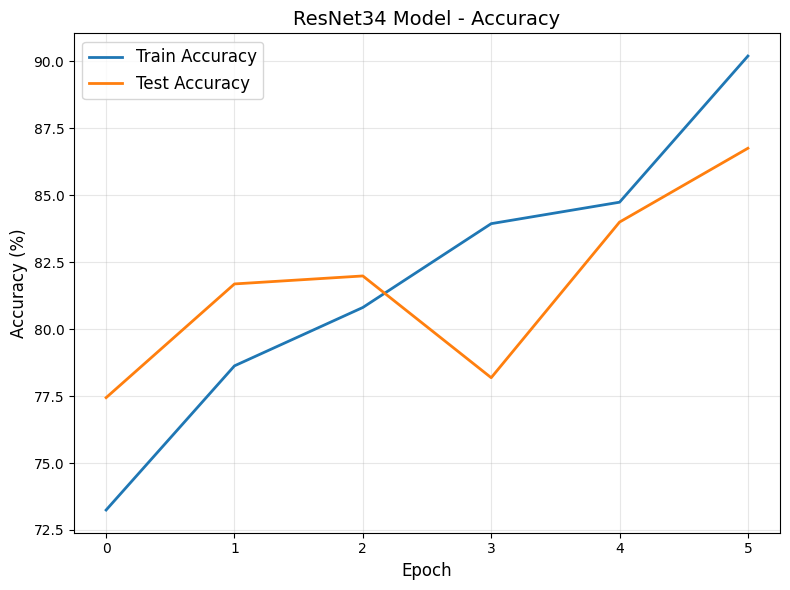


Точность на обучающей выборке:
Точность по классам:
  Agaricus    :  91.17% (258/283)
  Amanita     :  92.00% (552/600)
  Boletus     :  98.37% (844/858)
  Cortinarius :  88.94% (595/669)
  Entoloma    :  92.10% (268/291)
  Hygrocybe   :  94.07% (238/253)
  Lactarius   :  96.00% (1200/1250)
  Russula     :  93.14% (855/918)
  Suillus     :  88.35% (220/249)
  Общая точность: 93.65%

Точность на тестовой выборке:
Точность по классам:
  Agaricus    :  80.00% (56/70)
  Amanita     :  86.00% (129/150)
  Boletus     :  93.49% (201/215)
  Cortinarius :  74.85% (125/167)
  Entoloma    :  86.30% (63/73)
  Hygrocybe   :  92.06% (58/63)
  Lactarius   :  90.73% (284/313)
  Russula     :  86.96% (200/230)
  Suillus     :  79.03% (49/62)
  Общая точность: 86.75%

Матрица ошибок (тестовая выборка):


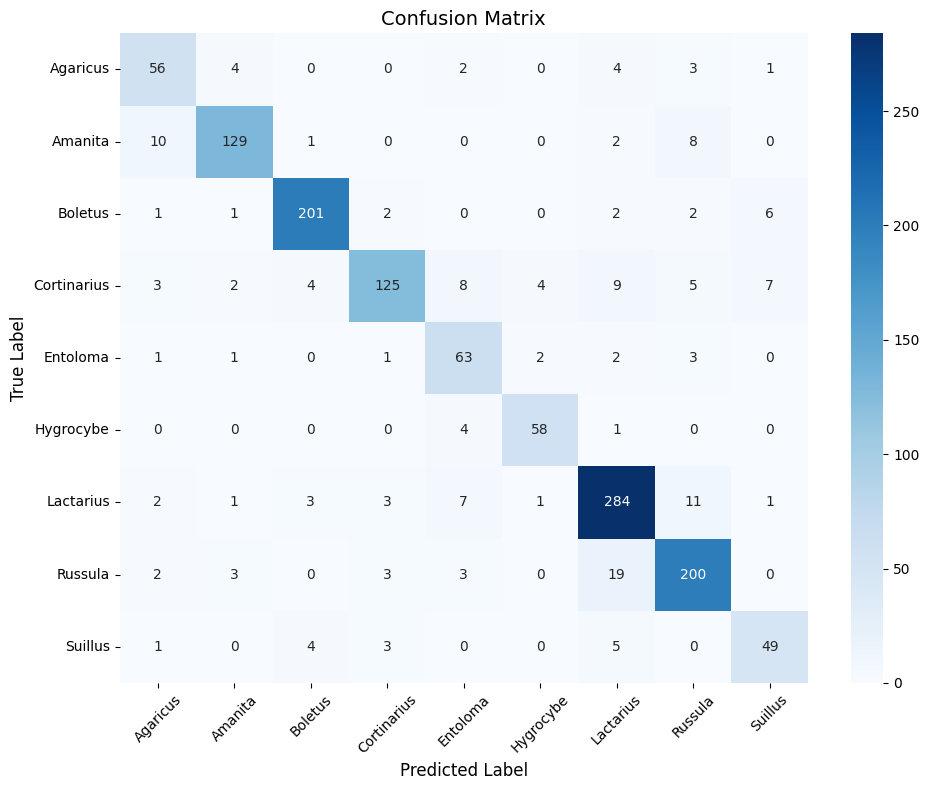

In [ ]:
# Обучаем модель
EPOCHS = 6

history = train_model(model, train_dataloader, test_dataloader, device, EPOCHS)

print("\nВизуализация результатов обучения...")
plot_training_history(history, "ResNet34 Model")

# Оценка точности
print("\nТочность на обучающей выборке:")
train_overall, train_preds, train_true = detailed_class_accuracy(
    model, train_dataloader, class_names, device
)

print("\nТочность на тестовой выборке:")
test_overall, test_preds, test_true = detailed_class_accuracy(
    model, test_dataloader, class_names, device
)

# Строим матрицу ошибок
print("\nМатрица ошибок (тестовая выборка):")
plot_confusion_matrix(test_true, test_preds, class_names)

# Сохраняем модель
torch.save(model.state_dict(), 'mushroom_resnet34_model.pth')